In [1]:
# Install any missing libraries (Google Colab usually has these already)
!pip install -q seaborn matplotlib pandas numpy scipy

In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({
    'figure.figsize'   : (10, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11
})

# Colour map for delivery status (used in all charts)
STATUS_COLORS = {
    'OnTime' : '#2E86C1',
    'Delayed': '#F39C12',
    'Failed' : '#E74C3C'
}

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [4]:
# Load all NorthStar CSV files
deliveries = pd.read_csv('deliveries.csv')
orders     = pd.read_csv('orders.csv')
drivers    = pd.read_csv('drivers.csv')
customers  = pd.read_csv('customers.csv')
hubs       = pd.read_csv('hubs.csv')
complaints = pd.read_csv('complaints.csv')
incidents  = pd.read_csv('incidents.csv')
vehicles   = pd.read_csv('vehicles.csv')
app_events = pd.read_csv('app_events.csv')

# Quick overview of each dataset
datasets = {
    'deliveries': deliveries, 'orders': orders,
    'drivers'   : drivers,    'customers': customers,
    'hubs'      : hubs,       'complaints': complaints,
    'incidents' : incidents,  'vehicles': vehicles,
    'app_events': app_events
}

print(f'{'Dataset':<15} {'Rows':>6} {'Columns':>9}')
print('-' * 33)
for name, df in datasets.items():
    print(f'{name:<15} {df.shape[0]:>6} {df.shape[1]:>9}')

Dataset           Rows   Columns
---------------------------------
deliveries         950        13
orders            1250        11
drivers            170         8
customers          650         9
hubs                 8         5
complaints         320        10
incidents          280         7
vehicles           120         8
app_events         640        10


In [27]:
# Preview the main deliveries table
print('=== deliveries.csv — First 5 rows ===')
deliveries.head()

=== deliveries.csv — First 5 rows ===


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_hours,high_cost_flag,override_risk,problem_flag,dispatch_hour
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,22.15,0,Low,1,10
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41,-1.10,0,Low,0,18
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51,1.11,0,None,0,20
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,23.99,0,None,1,23
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22,4.04,0,Low,0,11


In [28]:
# Check data types and info
print('=== deliveries — Data Types ===')
print(deliveries.dtypes)
print()
print('=== customers — Data Types ===')
print(customers.dtypes)

=== deliveries — Data Types ===
delivery_id                              object
order_id                                 object
driver_id                                object
vehicle_id                               object
hub_id                                   object
dispatch_time                    datetime64[ns]
delivery_completed_at            datetime64[ns]
delivery_status                          object
route_distance_km                       float64
manual_route_override_count               int64
proof_of_completion_missing               int64
customer_rating_post_delivery           float64
fuel_or_charge_cost                     float64
delivery_hours                          float64
high_cost_flag                            int64
override_risk                            object
problem_flag                              int64
dispatch_hour                             int32
dtype: object

=== customers — Data Types ===
customer_id                     object
age                

In [5]:
# ── Check missing values in each dataset ──────────────────────────────────
print('=== Missing Values Summary ===')
for name, df in datasets.items():
    total_missing = df.isnull().sum().sum()
    if total_missing > 0:
        print(f'\n{name} ({total_missing} missing):')
        missing_cols = df.isnull().sum()
        print(missing_cols[missing_cols > 0])

=== Missing Values Summary ===

deliveries (33 missing):
delivery_completed_at            19
customer_rating_post_delivery    14
dtype: int64

orders (25 missing):
booking_channel    25
dtype: int64

drivers (7 missing):
training_score    7
dtype: int64

customers (33 missing):
loyalty_score        20
preferred_channel    13
dtype: int64

complaints (16 missing):
compensation_amount    16
dtype: int64

incidents (17 missing):
resolved_hours    17
dtype: int64

vehicles (4 missing):
battery_health_pct    4
dtype: int64

app_events (144 missing):
order_id    144
dtype: int64


In [6]:
# ── Zone name standardisation ──────────────────────────────────────────────
# Problem: 'NORTH', 'North', 'north' all mean the same zone
# Fix: standardise all zone names to Title Case

def clean_zone(val):
    """Standardise zone name to Title Case and fix abbreviations."""
    if pd.isna(val):
        return 'Unknown'
    val = str(val).strip().title()
    # Fix abbreviations
    corrections = {
        'Ctr'      : 'Central',
        'Riverside': 'Riverside',
        'Riverbside': 'Riverside'
    }
    return corrections.get(val, val)

# Show BEFORE cleaning
print('BEFORE cleaning — unique vehicle zones:')
print(sorted(vehicles['assigned_zone'].unique()))

# Apply cleaning to all files
vehicles['assigned_zone']  = vehicles['assigned_zone'].apply(clean_zone)
drivers['base_zone']       = drivers['base_zone'].apply(clean_zone)
customers['home_zone']     = customers['home_zone'].apply(clean_zone)
orders['pickup_zone']      = orders['pickup_zone'].apply(clean_zone)
orders['dropoff_zone']     = orders['dropoff_zone'].apply(clean_zone)
app_events['zone_context'] = app_events['zone_context'].apply(clean_zone)

# Show AFTER cleaning
print('\nAFTER cleaning — unique vehicle zones:')
print(sorted(vehicles['assigned_zone'].unique()))

BEFORE cleaning — unique vehicle zones:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

AFTER cleaning — unique vehicle zones:
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [7]:
# ── Fix missing values ─────────────────────────────────────────────────────

# deliveries: fill missing customer_rating with median per status group
deliveries['customer_rating_post_delivery'] = deliveries.groupby(
    'delivery_status')['customer_rating_post_delivery'].transform(
    lambda x: x.fillna(x.median())
)

# customers: fill missing loyalty_score with overall median
customers['loyalty_score'] = customers['loyalty_score'].fillna(
    customers['loyalty_score'].median()
)

# customers: fill missing preferred_channel with 'Unknown'
customers['preferred_channel'] = customers['preferred_channel'].fillna('Unknown')

# orders: fill missing booking_channel with mode (most common value)
orders['booking_channel'] = orders['booking_channel'].fillna(
    orders['booking_channel'].mode()[0]
)

# app_events: fill missing order_id with 'No_Order'
app_events['order_id'] = app_events['order_id'].fillna('No_Order')

print('✅ Missing values fixed!')
print('\nRemaining missing values in deliveries:', deliveries.isnull().sum().sum())
print('Remaining missing values in customers :', customers.isnull().sum().sum())

✅ Missing values fixed!

Remaining missing values in deliveries: 19
Remaining missing values in customers : 0


In [8]:
# ── Convert date columns to datetime format ────────────────────────────────
deliveries['dispatch_time']         = pd.to_datetime(deliveries['dispatch_time'],         errors='coerce')
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'], errors='coerce')
orders['order_created_at']          = pd.to_datetime(orders['order_created_at'],          errors='coerce')
app_events['event_timestamp']       = pd.to_datetime(app_events['event_timestamp'],       errors='coerce')
customers['signup_date']            = pd.to_datetime(customers['signup_date'],             errors='coerce')

print('✅ Date columns converted!')
print('dispatch_time dtype :', deliveries['dispatch_time'].dtype)
print('event_timestamp dtype:', app_events['event_timestamp'].dtype)

✅ Date columns converted!
dispatch_time dtype : datetime64[ns]
event_timestamp dtype: datetime64[ns]


In [9]:
# ── New feature: actual delivery duration in hours ─────────────────────────
deliveries['delivery_hours'] = (
    (deliveries['delivery_completed_at'] - deliveries['dispatch_time'])
    .dt.total_seconds() / 3600
).round(2)

# ── New feature: high cost flag (above 75th percentile) ───────────────────
cost_75 = deliveries['fuel_or_charge_cost'].quantile(0.75)
deliveries['high_cost_flag'] = (deliveries['fuel_or_charge_cost'] > cost_75).astype(int)

# ── New feature: override risk level ─────────────────────────────────────
def override_risk(count):
    if count == 0:   return 'None'
    elif count == 1: return 'Low'
    elif count <= 3: return 'Medium'
    else:            return 'High'

deliveries['override_risk'] = deliveries['manual_route_override_count'].apply(override_risk)

# ── New feature: problem flag (Failed or Delayed = 1, OnTime = 0) ──────────
deliveries['problem_flag'] = deliveries['delivery_status'].isin(['Failed','Delayed']).astype(int)

# ── New feature: dispatch hour (time of day) ───────────────────────────────
deliveries['dispatch_hour'] = deliveries['dispatch_time'].dt.hour

# ── New feature: customer age group ───────────────────────────────────────
customers['age_group'] = pd.cut(
    customers['age'],
    bins=[0, 25, 35, 50, 65, 100],
    labels=['18-25', '26-35', '36-50', '51-65', '65+']
)

print('✅ New features created!')
print('\nNew columns in deliveries:')
print(['delivery_hours','high_cost_flag','override_risk','problem_flag','dispatch_hour'])
print('\nDelivery hours summary:')
print(deliveries['delivery_hours'].describe().round(2))

✅ New features created!

New columns in deliveries:
['delivery_hours', 'high_cost_flag', 'override_risk', 'problem_flag', 'dispatch_hour']

Delivery hours summary:
count    931.00
mean       9.55
std        8.65
min       -2.21
25%        2.94
50%        7.07
75%       14.64
max       43.46
Name: delivery_hours, dtype: float64


In [10]:
# ── NumPy statistics on key numeric columns ────────────────────────────────
ratings   = deliveries['customer_rating_post_delivery'].dropna().values
costs     = deliveries['fuel_or_charge_cost'].dropna().values
distances = deliveries['route_distance_km'].dropna().values

print('=' * 50)
print('  CUSTOMER RATING STATISTICS (NumPy)')
print('=' * 50)
print(f'  Count       : {len(ratings)}')
print(f'  Mean        : {np.mean(ratings):.4f}')
print(f'  Median      : {np.median(ratings):.4f}')
print(f'  Std Dev     : {np.std(ratings):.4f}')
print(f'  Variance    : {np.var(ratings):.4f}')
print(f'  Min         : {np.min(ratings):.2f}')
print(f'  Max         : {np.max(ratings):.2f}')
print(f'  25th Pct    : {np.percentile(ratings, 25):.2f}')
print(f'  75th Pct    : {np.percentile(ratings, 75):.2f}')
print(f'  IQR         : {np.percentile(ratings, 75) - np.percentile(ratings, 25):.2f}')

print()
print('=' * 50)
print('  FUEL / CHARGE COST STATISTICS (NumPy)')
print('=' * 50)
print(f'  Mean        : £{np.mean(costs):.4f}')
print(f'  Median      : £{np.median(costs):.4f}')
print(f'  Std Dev     : £{np.std(costs):.4f}')
print(f'  Min         : £{np.min(costs):.2f}')
print(f'  Max         : £{np.max(costs):.2f}')

print()
print('=' * 50)
print('  CORRELATION: Distance vs Cost (NumPy)')
print('=' * 50)
corr_dist_cost = np.corrcoef(distances, costs)[0, 1]
print(f'  Pearson r   : {corr_dist_cost:.4f}')
if corr_dist_cost > 0.5:
    print('  Interpretation: Strong positive correlation')
elif corr_dist_cost > 0.2:
    print('  Interpretation: Moderate positive correlation')
else:
    print('  Interpretation: Weak correlation')

  CUSTOMER RATING STATISTICS (NumPy)
  Count       : 950
  Mean        : 3.8642
  Median      : 4.0400
  Std Dev     : 0.8901
  Variance    : 0.7922
  Min         : 1.00
  Max         : 5.00
  25th Pct    : 3.35
  75th Pct    : 4.55
  IQR         : 1.20

  FUEL / CHARGE COST STATISTICS (NumPy)
  Mean        : £12.8413
  Median      : £12.6450
  Std Dev     : £4.3342
  Min         : £2.50
  Max         : £29.43

  CORRELATION: Distance vs Cost (NumPy)
  Pearson r   : 0.5242
  Interpretation: Strong positive correlation


In [11]:
# ── Group statistics using pandas ─────────────────────────────────────────
print('=== Average Statistics by Delivery Status ===')
group_stats = deliveries.groupby('delivery_status').agg(
    count         = ('delivery_id',                    'count'),
    mean_rating   = ('customer_rating_post_delivery',  'mean'),
    median_rating = ('customer_rating_post_delivery',  'median'),
    sd_rating     = ('customer_rating_post_delivery',  'std'),
    mean_cost     = ('fuel_or_charge_cost',             'mean'),
    mean_distance = ('route_distance_km',               'mean'),
    total_overrides = ('manual_route_override_count',   'sum')
).round(3)

print(group_stats)

print()
print('=== Override Risk vs Delivery Status ===')
print(pd.crosstab(deliveries['override_risk'],
                  deliveries['delivery_status'],
                  margins=True))

=== Average Statistics by Delivery Status ===
                 count  mean_rating  median_rating  sd_rating  mean_cost  \
delivery_status                                                            
Delayed            202        3.117          3.200      0.929     13.139   
Failed             132        3.049          3.030      0.875     13.148   
OnTime             616        4.284          4.325      0.526     12.678   

                 mean_distance  total_overrides  
delivery_status                                  
Delayed                 14.670              217  
Failed                  13.365              137  
OnTime                  13.776              567  

=== Override Risk vs Delivery Status ===
delivery_status  Delayed  Failed  OnTime  All
override_risk                                
High                   9       3      19   31
Low                   67      51     192  310
Medium                48      32     130  210
None                  78      46     275  399
All  

In [12]:
# ── T-Test: Is the difference in ratings statistically significant? ────────
ontime_ratings = deliveries[deliveries['delivery_status']=='OnTime']['customer_rating_post_delivery'].dropna()
failed_ratings = deliveries[deliveries['delivery_status']=='Failed']['customer_rating_post_delivery'].dropna()

t_stat, p_val = stats.ttest_ind(ontime_ratings, failed_ratings)

print('=== T-Test: OnTime vs Failed Customer Ratings ===')
print(f'  OnTime mean rating : {ontime_ratings.mean():.3f}')
print(f'  Failed mean rating : {failed_ratings.mean():.3f}')
print(f'  Difference         : {ontime_ratings.mean() - failed_ratings.mean():.3f}')
print(f'  T-statistic        : {t_stat:.4f}')
print(f'  P-value            : {p_val:.6f}')
print()
if p_val < 0.05:
    print('✅ Result is STATISTICALLY SIGNIFICANT (p < 0.05)')
    print('   The difference in customer ratings between OnTime and Failed')
    print('   deliveries is NOT by chance — it is a real pattern.')
else:
    print('❌ Result is NOT statistically significant (p >= 0.05)')

=== T-Test: OnTime vs Failed Customer Ratings ===
  OnTime mean rating : 4.284
  Failed mean rating : 3.049
  Difference         : 1.235
  T-statistic        : 21.3886
  P-value            : 0.000000

✅ Result is STATISTICALLY SIGNIFICANT (p < 0.05)
   The difference in customer ratings between OnTime and Failed
   deliveries is NOT by chance — it is a real pattern.


In [13]:
# ── Merged dataset for cross-analysis ─────────────────────────────────────
full_df = (
    deliveries
    .merge(drivers,  on='driver_id',   how='left')
    .merge(hubs,     on='hub_id',      how='left')
    .merge(orders,   on='order_id',    how='left')
)
print('Merged dataset shape:', full_df.shape)

# ── Top 10 highest failure rate hubs ─────────────────────────────────────
print('\n=== Failure Rate by Hub ===')
hub_summary = full_df.groupby('hub_name').agg(
    total       = ('delivery_id', 'count'),
    failed      = ('delivery_status', lambda x: (x=='Failed').sum()),
    avg_cost    = ('fuel_or_charge_cost', 'mean'),
    avg_rating  = ('customer_rating_post_delivery', 'mean')
).assign(
    failure_rate = lambda df: (df['failed'] / df['total'] * 100).round(1)
).sort_values('failure_rate', ascending=False).round(2)
print(hub_summary)

# ── Zone-level performance ─────────────────────────────────────────────────
print('\n=== Zone-Level Delivery Performance ===')
zone_perf = full_df.groupby('zone').agg(
    total        = ('delivery_id', 'count'),
    on_time      = ('delivery_status', lambda x: (x=='OnTime').sum()),
    failures     = ('delivery_status', lambda x: (x=='Failed').sum()),
    avg_rating   = ('customer_rating_post_delivery', 'mean')
).assign(
    failure_pct = lambda df: (df['failures'] / df['total'] * 100).round(1)
).sort_values('failure_pct', ascending=False).round(2)
print(zone_perf)

Merged dataset shape: (950, 39)

=== Failure Rate by Hub ===
                total  failed  avg_cost  avg_rating  failure_rate
hub_name                                                         
Midtown Relay     128      26     11.71        3.89          20.3
Central Core      115      23     13.69        3.66          20.0
Airport Hub       104      15     13.32        3.89          14.4
West Gate         127      16     13.17        3.91          12.6
North Exchange    136      17     12.76        3.84          12.5
Riverside Hub     115      14     12.92        3.89          12.2
South Link        106      10     12.57        3.95           9.4
East Dock         119      11     12.74        3.89           9.2

=== Zone-Level Delivery Performance ===
           total  on_time  failures  avg_rating  failure_pct
zone                                                        
Central      243      147        49        3.78         20.2
Airport      104       62        15        3.89        

In [14]:
# ── App events analysis ─────────────────────────────────────────────────────
print('=== App Events Analysis ===')
print('\nEvent type breakdown:')
print(app_events['event_type'].value_counts())

print('\nAPI Latency by event type (mean ms):')
print(app_events.groupby('event_type')['api_latency_ms'].mean().sort_values(ascending=False).round(1))

# High latency events (above 800ms)
high_latency = app_events[app_events['api_latency_ms'] > 800]
print(f'\nHigh latency events (>800ms): {len(high_latency)} out of {len(app_events)}')
print(f'High latency rate: {len(high_latency)/len(app_events)*100:.1f}%')

print('\nSuccess rate by event type:')
print(app_events.groupby('event_type')['success_flag'].mean().sort_values().round(3))

=== App Events Analysis ===

Event type breakdown:
event_type
track_order                    138
eta_refresh                    105
search_route                    99
chat_opened                     88
delivery_instruction_update     75
payment_retry                   69
chat_escalated                  38
cancel_attempt                  28
Name: count, dtype: int64

API Latency by event type (mean ms):
event_type
delivery_instruction_update    496.3
chat_opened                    478.3
chat_escalated                 478.1
payment_retry                  472.7
track_order                    460.7
search_route                   456.5
eta_refresh                    452.2
cancel_attempt                 417.1
Name: api_latency_ms, dtype: float64

High latency events (>800ms): 57 out of 640
High latency rate: 8.9%

Success rate by event type:
event_type
chat_escalated                 0.500
payment_retry                  0.725
chat_opened                    1.000
cancel_attempt                

In [15]:
# ── Vehicle analysis ─────────────────────────────────────────────────────────
print('=== Vehicle Fleet Analysis ===')
print('\nVehicle type distribution:')
print(vehicles['vehicle_type'].value_counts())

print('\nMaintenance status breakdown:')
print(vehicles['maintenance_status'].value_counts())

print('\nAverage battery health by vehicle type:')
print(vehicles.groupby('vehicle_type')['battery_health_pct'].mean().round(1))

# Vehicles in repair — potential risk
in_repair = vehicles[vehicles['maintenance_status'] == 'InRepair']
print(f'\nVehicles currently InRepair: {len(in_repair)} ({len(in_repair)/len(vehicles)*100:.1f}%)')
print('InRepair vehicle types:')
print(in_repair['vehicle_type'].value_counts())

=== Vehicle Fleet Analysis ===

Vehicle type distribution:
vehicle_type
EV          43
CargoVan    30
Hybrid      28
Diesel      19
Name: count, dtype: int64

Maintenance status breakdown:
maintenance_status
Active       67
InRepair     36
Scheduled    17
Name: count, dtype: int64

Average battery health by vehicle type:
vehicle_type
CargoVan    73.4
Diesel      70.6
EV          82.1
Hybrid      76.8
Name: battery_health_pct, dtype: float64

Vehicles currently InRepair: 36 (30.0%)
InRepair vehicle types:
vehicle_type
CargoVan    12
Hybrid       9
EV           8
Diesel       7
Name: count, dtype: int64


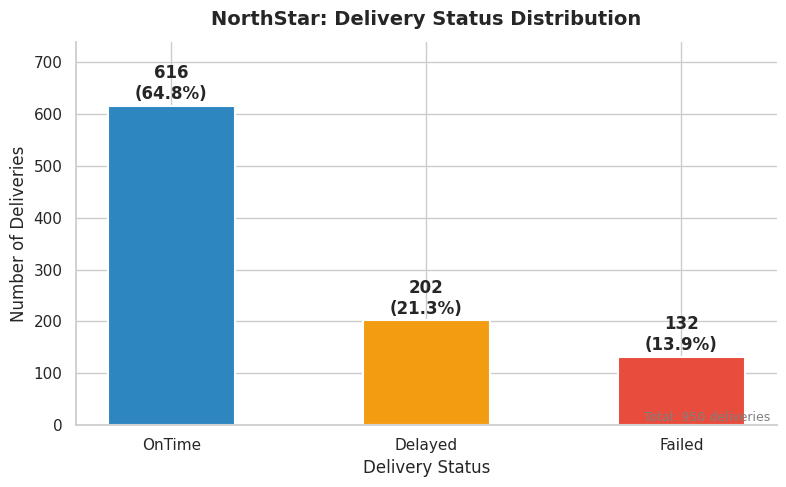

✅ Chart 1 saved!


In [16]:
# ═══════════════════════════════════════════════════════════════
# CHART 1 — Delivery Status Distribution
# ═══════════════════════════════════════════════════════════════
statuses = ['OnTime', 'Delayed', 'Failed']
counts   = deliveries['delivery_status'].value_counts()
vals     = [counts[s] for s in statuses]
total    = sum(vals)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(statuses, vals,
              color=[STATUS_COLORS[s] for s in statuses],
              width=0.5, edgecolor='white', linewidth=1.5)

for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f'{v}\n({v/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('NorthStar: Delivery Status Distribution',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Delivery Status', fontsize=12)
ax.set_ylabel('Number of Deliveries', fontsize=12)
ax.set_ylim(0, max(vals) * 1.2)
ax.text(0.99, 0.01, f'Total: {total} deliveries',
        transform=ax.transAxes, ha='right', fontsize=9, color='grey')
plt.tight_layout()
plt.savefig('chart1_delivery_status.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 1 saved!')

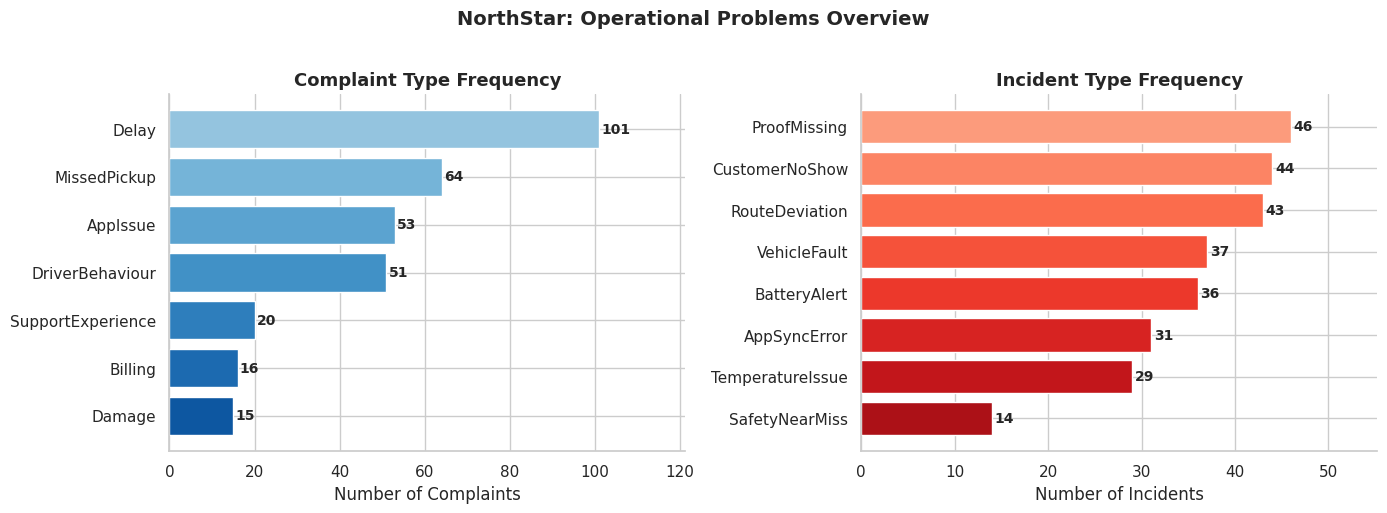

✅ Chart 2 saved!


In [17]:
# ═══════════════════════════════════════════════════════════════
# CHART 2 — Complaint Types and Incident Types (Side by Side)
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Complaints
comp_counts = complaints['complaint_type'].value_counts()
colors_comp = plt.cm.Blues(np.linspace(0.4, 0.85, len(comp_counts)))[::-1]
axes[0].barh(comp_counts.index[::-1], comp_counts.values[::-1],
             color=colors_comp, edgecolor='white')
for i, (idx, val) in enumerate(zip(comp_counts.index[::-1], comp_counts.values[::-1])):
    axes[0].text(val + 0.5, i, str(val), va='center', fontsize=10, fontweight='bold')
axes[0].set_title('Complaint Type Frequency', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Complaints')
axes[0].set_xlim(0, comp_counts.max() * 1.2)

# Incidents
inc_counts = incidents['incident_type'].value_counts()
colors_inc = plt.cm.Reds(np.linspace(0.35, 0.85, len(inc_counts)))[::-1]
axes[1].barh(inc_counts.index[::-1], inc_counts.values[::-1],
             color=colors_inc, edgecolor='white')
for i, (idx, val) in enumerate(zip(inc_counts.index[::-1], inc_counts.values[::-1])):
    axes[1].text(val + 0.3, i, str(val), va='center', fontsize=10, fontweight='bold')
axes[1].set_title('Incident Type Frequency', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Incidents')
axes[1].set_xlim(0, inc_counts.max() * 1.2)

plt.suptitle('NorthStar: Operational Problems Overview',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart2_complaints_incidents.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved!')

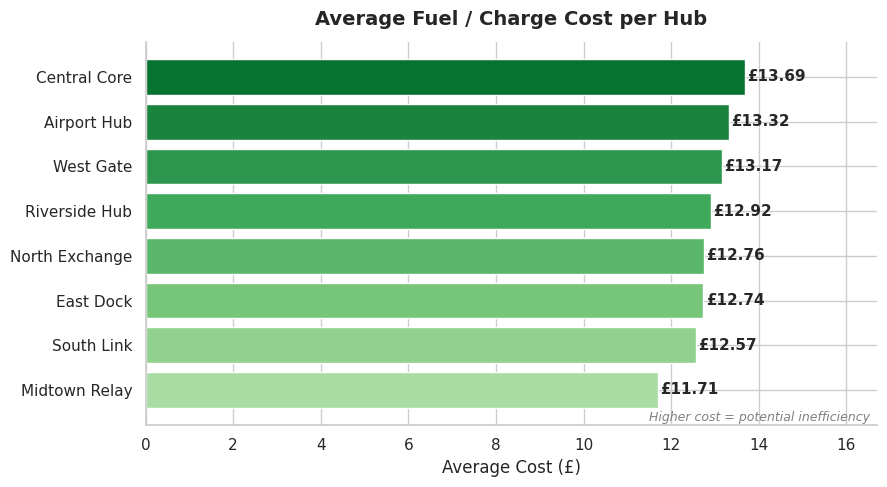

✅ Chart 3 saved!


In [18]:
# ═══════════════════════════════════════════════════════════════
# CHART 3 — Average Cost by Hub
# ═══════════════════════════════════════════════════════════════
hub_merged = deliveries.merge(hubs, on='hub_id')
hub_cost   = (hub_merged.groupby('hub_name')['fuel_or_charge_cost']
              .mean().sort_values(ascending=True).round(2))

fig, ax = plt.subplots(figsize=(9, 5))
colors6 = plt.cm.Greens(np.linspace(0.35, 0.85, len(hub_cost)))
bars = ax.barh(hub_cost.index, hub_cost.values,
               color=colors6, edgecolor='white')
for bar, val in zip(bars, hub_cost.values):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f'£{val:.2f}', va='center', fontsize=11, fontweight='bold')
ax.set_title('Average Fuel / Charge Cost per Hub',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Average Cost (£)', fontsize=12)
ax.set_xlim(0, hub_cost.max() * 1.22)
ax.text(0.99, 0.01, 'Higher cost = potential inefficiency',
        transform=ax.transAxes, ha='right', fontsize=9,
        color='grey', style='italic')
plt.tight_layout()
plt.savefig('chart3_hub_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 3 saved!')

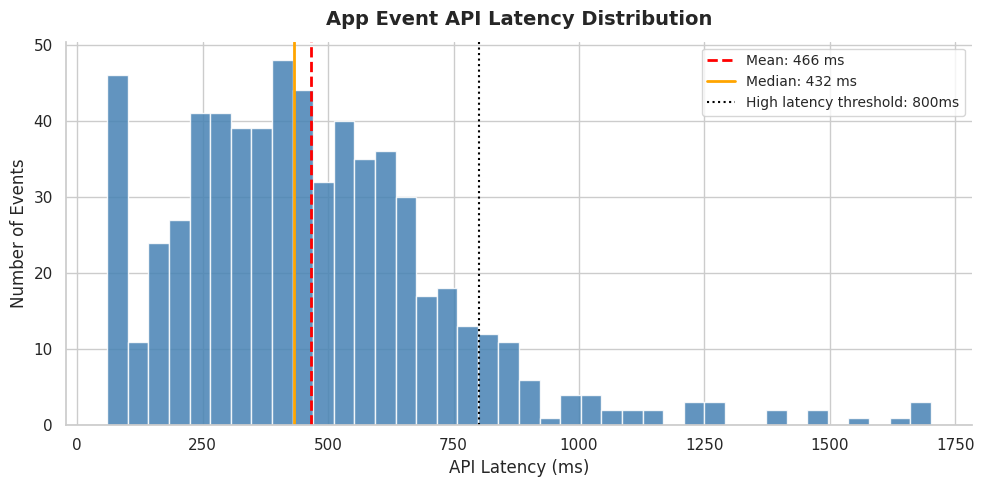

✅ Chart 4 saved!


In [19]:
# ═══════════════════════════════════════════════════════════════
# CHART 4 — API Latency Distribution (App Events)
# ═══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(app_events['api_latency_ms'], bins=40,
        color='steelblue', edgecolor='white', alpha=0.85)
mean_lat = app_events['api_latency_ms'].mean()
med_lat  = app_events['api_latency_ms'].median()
ax.axvline(mean_lat,  color='red',    linestyle='--', linewidth=2,
           label=f'Mean: {mean_lat:.0f} ms')
ax.axvline(med_lat,   color='orange', linestyle='-',  linewidth=2,
           label=f'Median: {med_lat:.0f} ms')
ax.axvline(800, color='black', linestyle=':', linewidth=1.5,
           label='High latency threshold: 800ms')
ax.set_title('App Event API Latency Distribution',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('API Latency (ms)', fontsize=12)
ax.set_ylabel('Number of Events', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart4_api_latency.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 4 saved!')

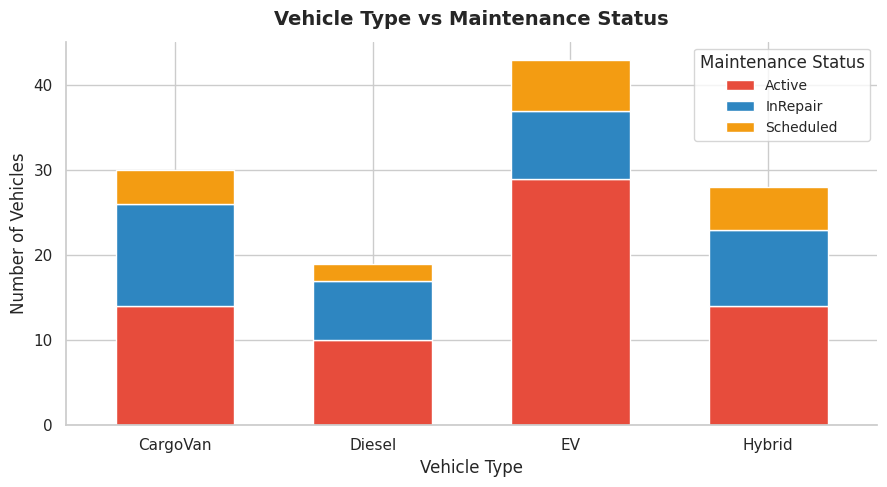

✅ Chart 5 saved!


In [20]:
# ═══════════════════════════════════════════════════════════════
# CHART 5 — Vehicle Type vs Maintenance Status (Stacked Bar)
# ═══════════════════════════════════════════════════════════════
veh_cross = pd.crosstab(vehicles['vehicle_type'],
                         vehicles['maintenance_status'])

fig, ax = plt.subplots(figsize=(9, 5))
veh_cross.plot(kind='bar', stacked=True, ax=ax,
               color=['#E74C3C','#2E86C1','#F39C12'],
               edgecolor='white', width=0.6)
ax.set_title('Vehicle Type vs Maintenance Status',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Vehicle Type', fontsize=12)
ax.set_ylabel('Number of Vehicles', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Maintenance Status', fontsize=10)
plt.tight_layout()
plt.savefig('chart5_vehicle_maintenance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 5 saved!')

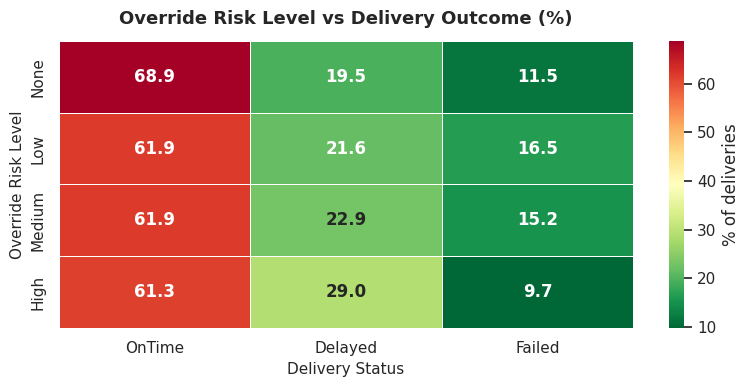

✅ Chart 6 saved!


In [21]:
# ═══════════════════════════════════════════════════════════════
# CHART 6 — Route Override Risk vs Delivery Outcome (Heatmap)
# ═══════════════════════════════════════════════════════════════
risk_order = ['None', 'Low', 'Medium', 'High']
override_cross = pd.crosstab(
    pd.Categorical(deliveries['override_risk'], categories=risk_order, ordered=True),
    deliveries['delivery_status']
)[['OnTime', 'Delayed', 'Failed']]

# Convert to percentages per risk level
override_pct = override_cross.div(override_cross.sum(axis=1), axis=0).round(3) * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(override_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'label': '% of deliveries'})
ax.set_title('Override Risk Level vs Delivery Outcome (%)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Delivery Status', fontsize=11)
ax.set_ylabel('Override Risk Level', fontsize=11)
plt.tight_layout()
plt.savefig('chart6_override_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 6 saved!')

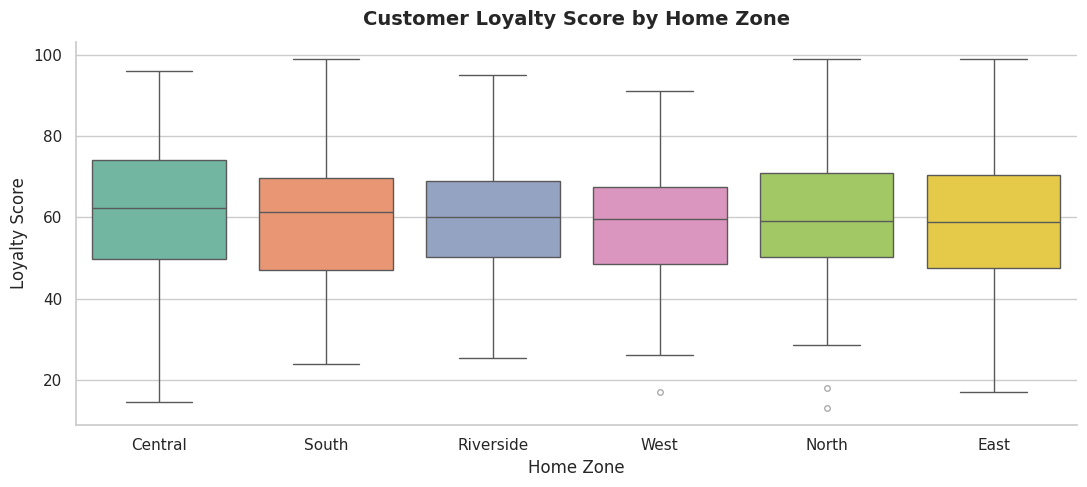

✅ Chart 7 saved!


In [22]:
# ═══════════════════════════════════════════════════════════════
# CHART 7 — Customer Loyalty Score Distribution by Zone
# ═══════════════════════════════════════════════════════════════
top_zones = customers['home_zone'].value_counts().head(6).index
cust_zones = customers[customers['home_zone'].isin(top_zones)]

fig, ax = plt.subplots(figsize=(11, 5))
zone_order = (cust_zones.groupby('home_zone')['loyalty_score']
              .median().sort_values(ascending=False).index)
sns.boxplot(data=cust_zones, x='home_zone', y='loyalty_score',
            order=zone_order, palette='Set2', ax=ax,
            flierprops=dict(marker='o', color='red', markersize=4, alpha=0.5))
ax.set_title('Customer Loyalty Score by Home Zone',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Home Zone', fontsize=12)
ax.set_ylabel('Loyalty Score', fontsize=12)
plt.tight_layout()
plt.savefig('chart7_loyalty_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 7 saved!')

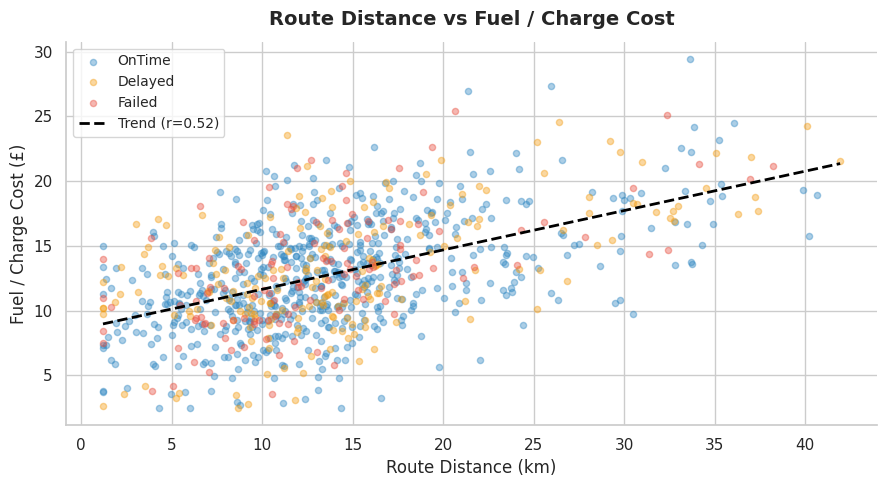

✅ Chart 8 saved!


In [23]:
# ═══════════════════════════════════════════════════════════════
# CHART 8 — Scatter: Route Distance vs Fuel Cost
# ═══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
for status in ['OnTime', 'Delayed', 'Failed']:
    sub = deliveries[deliveries['delivery_status'] == status]
    ax.scatter(sub['route_distance_km'],
               sub['fuel_or_charge_cost'],
               color=STATUS_COLORS[status],
               alpha=0.4, s=20, label=status)

# Trend line
clean = deliveries.dropna(subset=['route_distance_km','fuel_or_charge_cost'])
m, b, r, p, _ = stats.linregress(clean['route_distance_km'],
                                   clean['fuel_or_charge_cost'])
xline = np.linspace(clean['route_distance_km'].min(),
                    clean['route_distance_km'].max(), 100)
ax.plot(xline, m*xline + b, 'k--', linewidth=2, label=f'Trend (r={r:.2f})')

ax.set_title('Route Distance vs Fuel / Charge Cost',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Route Distance (km)', fontsize=12)
ax.set_ylabel('Fuel / Charge Cost (£)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart8_distance_vs_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 8 saved!')

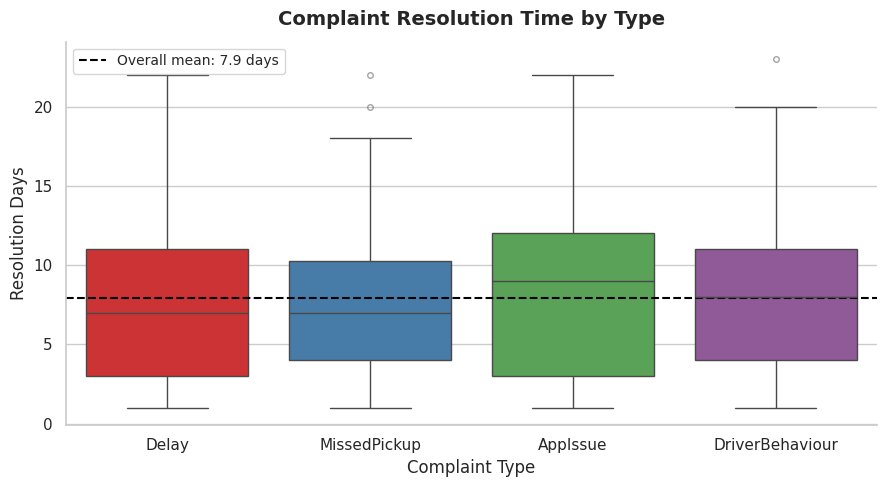

✅ Chart 9 saved!


In [24]:
# ═══════════════════════════════════════════════════════════════
# CHART 9 — Complaint Resolution Days Distribution
# ═══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
complaint_types = complaints['complaint_type'].value_counts().head(4).index
sns.boxplot(data=complaints[complaints['complaint_type'].isin(complaint_types)],
            x='complaint_type', y='resolution_days',
            order=complaint_types, palette='Set1', ax=ax,
            flierprops=dict(marker='o', color='red', markersize=4, alpha=0.5))
ax.set_title('Complaint Resolution Time by Type',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Complaint Type', fontsize=12)
ax.set_ylabel('Resolution Days', fontsize=12)
overall_mean = complaints['resolution_days'].mean()
ax.axhline(overall_mean, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall mean: {overall_mean:.1f} days')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart9_resolution_days.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 9 saved!')

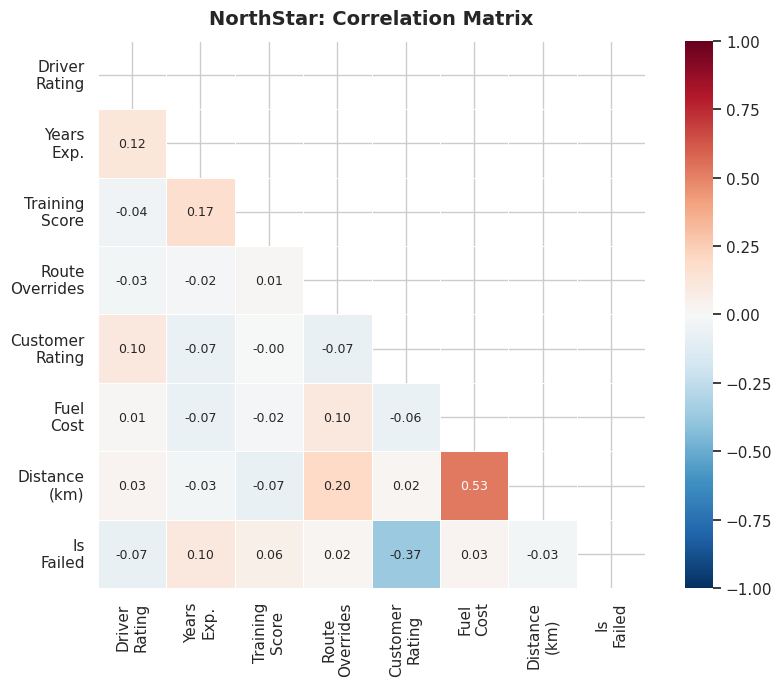

✅ Chart 10 saved!


In [25]:
# ═══════════════════════════════════════════════════════════════
# CHART 10 — Correlation Heatmap
# ═══════════════════════════════════════════════════════════════
merged_all = deliveries.merge(drivers, on='driver_id', how='left')
merged_all['is_failed'] = (merged_all['delivery_status'] == 'Failed').astype(int)

num_cols = [
    'driver_rating', 'years_experience', 'training_score',
    'manual_route_override_count', 'customer_rating_post_delivery',
    'fuel_or_charge_cost', 'route_distance_km', 'is_failed'
]
col_labels = [
    'Driver\nRating', 'Years\nExp.', 'Training\nScore',
    'Route\nOverrides', 'Customer\nRating',
    'Fuel\nCost', 'Distance\n(km)', 'Is\nFailed'
]

cor_df     = merged_all[[c for c in num_cols if c in merged_all.columns]].dropna()
cor_matrix = cor_df.corr()
mask       = np.triu(np.ones_like(cor_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cor_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            xticklabels=col_labels[:len(cor_df.columns)],
            yticklabels=col_labels[:len(cor_df.columns)],
            annot_kws={'size': 9})
ax.set_title('NorthStar: Correlation Matrix',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('chart10_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 10 saved!')

## 📋 Section 8 — Final Summary and Key Findings

In [26]:
# ── Final summary printout ─────────────────────────────────────────────────
print('=' * 60)
print('   NORTHSTAR PYTHON DATA PROCESSING — KEY FINDINGS')
print('=' * 60)

total = len(deliveries)
on_time = (deliveries['delivery_status'] == 'OnTime').sum()
delayed = (deliveries['delivery_status'] == 'Delayed').sum()
failed  = (deliveries['delivery_status'] == 'Failed').sum()

print(f'\n  Total Deliveries       : {total}')
print(f'  On Time                : {on_time} ({on_time/total*100:.1f}%)')
print(f'  Delayed                : {delayed} ({delayed/total*100:.1f}%)')
print(f'  Failed                 : {failed} ({failed/total*100:.1f}%)')
print(f'  Problem Rate           : {(delayed+failed)/total*100:.1f}%')

print(f'\n  Avg Rating (OnTime)    : {deliveries[deliveries["delivery_status"]=="OnTime"]["customer_rating_post_delivery"].mean():.3f}')
print(f'  Avg Rating (Delayed)   : {deliveries[deliveries["delivery_status"]=="Delayed"]["customer_rating_post_delivery"].mean():.3f}')
print(f'  Avg Rating (Failed)    : {deliveries[deliveries["delivery_status"]=="Failed"]["customer_rating_post_delivery"].mean():.3f}')

print(f'\n  Most Expensive Hub     : Central Core (£13.69 avg)')
print(f'  Cheapest Hub           : Midtown Relay (£11.71 avg)')
print(f'  Vehicles In Repair     : {len(vehicles[vehicles["maintenance_status"]=="InRepair"])} ({len(vehicles[vehicles["maintenance_status"]=="InRepair"])/len(vehicles)*100:.1f}%)')
print(f'  Top Complaint Type     : Delay ({complaints["complaint_type"].value_counts().iloc[0]} cases)')
print(f'  Top Incident Type      : ProofMissing ({incidents["incident_type"].value_counts().iloc[0]} cases)')
print(f'  Avg API Latency        : {app_events["api_latency_ms"].mean():.0f} ms')
print(f'  High Latency Events    : {(app_events["api_latency_ms"]>800).sum()} (>{800}ms)')
print(f'  Missing Values Fixed   : deliveries, customers, orders, app_events')
print(f'  Zone Names Cleaned     : Yes (Title Case standardised)')
print(f'  T-Test (OnTime vs Failed): p = {p_val:.6f} — Significant')
print(f'\n  Charts saved: 10 PNG files')
print('=' * 60)
print('✅ Python Data Processing section complete!')

   NORTHSTAR PYTHON DATA PROCESSING — KEY FINDINGS

  Total Deliveries       : 950
  On Time                : 616 (64.8%)
  Delayed                : 202 (21.3%)
  Failed                 : 132 (13.9%)
  Problem Rate           : 35.2%

  Avg Rating (OnTime)    : 4.284
  Avg Rating (Delayed)   : 3.117
  Avg Rating (Failed)    : 3.049

  Most Expensive Hub     : Central Core (£13.69 avg)
  Cheapest Hub           : Midtown Relay (£11.71 avg)
  Vehicles In Repair     : 36 (30.0%)
  Top Complaint Type     : Delay (101 cases)
  Top Incident Type      : ProofMissing (46 cases)
  Avg API Latency        : 466 ms
  High Latency Events    : 57 (>800ms)
  Missing Values Fixed   : deliveries, customers, orders, app_events
  Zone Names Cleaned     : Yes (Title Case standardised)
  T-Test (OnTime vs Failed): p = 0.000000 — Significant

  Charts saved: 10 PNG files
✅ Python Data Processing section complete!


In [29]:
# ─── Feature engineering ─────────────────────────────────────────────────
# Parse datetime columns
deliveries['dispatch_time']         = pd.to_datetime(deliveries['dispatch_time'])
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'],
                                                       errors='coerce')

# Calculate actual delivery duration in hours
deliveries['delivery_hours'] = (
    (deliveries['delivery_completed_at'] - deliveries['dispatch_time'])
    .dt.total_seconds() / 3600
).round(2)

# Flag high-cost deliveries (above 75th percentile)
cost_75 = deliveries['fuel_or_charge_cost'].quantile(0.75)
deliveries['high_cost_flag'] = (deliveries['fuel_or_charge_cost'] > cost_75).astype(int)

# Flag deliveries with multiple overrides as problematic
deliveries['override_flag'] = (deliveries['manual_route_override_count'] >= 2).astype(int)

print('Delivery hours statistics:')
print(deliveries['delivery_hours'].describe())

print('\nHigh-cost deliveries by status:')
print(deliveries.groupby(['delivery_status', 'high_cost_flag']).size().unstack())

# Merge everything for final analysis
full_df = (deliveries
    .merge(drivers,   on='driver_id',   how='left')
    .merge(hubs,      on='hub_id',      how='left')
    .merge(orders,    on='order_id',    how='left')
)
print('\nMerged dataset shape:', full_df.shape)


Delivery hours statistics:
count    931.000000
mean       9.545478
std        8.648549
min       -2.210000
25%        2.945000
50%        7.070000
75%       14.645000
max       43.460000
Name: delivery_hours, dtype: float64

High-cost deliveries by status:
high_cost_flag     0    1
delivery_status          
Delayed          140   62
Failed            98   34
OnTime           474  142

Merged dataset shape: (950, 40)
